In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_excel("salidas.xlsx")
df1.head()

,Linea,Estacion,Acceso_Estacion,Intervalo,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,_2025_06_06,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general
0,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:00:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:15:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:30:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:45:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,01:00:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
#borrar la columna de total_general
df1 = df1.drop('total_general', axis=1)

#crear una columna con las sumas
df1['total_general'] = df1.iloc[:, 4:34].sum(axis=1)

In [4]:
df1 = df1[["Intervalo", "total_general"]]

#Eliminar las horas fuera de horario
for i in range(0, 9):
    df1 = df1[df1['Intervalo'] != df1.loc[i, "Intervalo"]]

for i in range(86, 89):
    df1 = df1[df1['Intervalo'] != df1.loc[i, "Intervalo"]]

df1 = df1[ (df1['Intervalo'] != '02:30:00') & (df1['Intervalo'] != '02:45:00') ]
df1.reset_index()

,index,Intervalo,total_general
0,9,04:00:00,0
1,10,04:15:00,0
2,11,04:30:00,0
3,12,04:45:00,2
4,13,05:00:00,0
...,...,...,...
43689,50368,22:00:00,0
43690,50369,22:15:00,0
43691,50370,22:30:00,0
43692,50371,22:45:00,0


# Datos empleados
Se va a emplear el aumulado de salidas registrado en cada hora

In [5]:
df1c = df1.groupby(['Intervalo'], as_index=False)['total_general'].sum()
df1c.head()

,Intervalo,total_general
0,04:00:00,10795
1,04:15:00,15806
2,04:30:00,23025
3,04:45:00,44052
4,05:00:00,98748


In [6]:
#expresar la hora como número real

def hora_real(hora_texto):
    # Separar el texto por los dos puntos
    partes = str(hora_texto).split(':')
    
    # Extraer horas y minutos como números enteros
    horas = int(partes[0])
    minutos = int(partes[1])
    
    # Calcular la hora decimal (los minutos se dividen entre 60)
    return horas + (minutos / 60)

# Aplicar la función a la columna y crear una nueva
df1c['Hora'] = df1c['Intervalo'].apply(hora_real)
df1c.head()

,Intervalo,total_general,Hora
0,04:00:00,10795,4.00
1,04:15:00,15806,4.25
2,04:30:00,23025,4.50
3,04:45:00,44052,4.75
4,05:00:00,98748,5.00


In [7]:
df1c['Acumulado'] = df1c['total_general'].cumsum()
df1c.head()

,Intervalo,total_general,Hora,Acumulado
0,04:00:00,10795,4.00,10795
1,04:15:00,15806,4.25,26601
2,04:30:00,23025,4.50,49626
3,04:45:00,44052,4.75,93678
4,05:00:00,98748,5.00,192426


<function matplotlib.pyplot.show(close=None, block=None)>

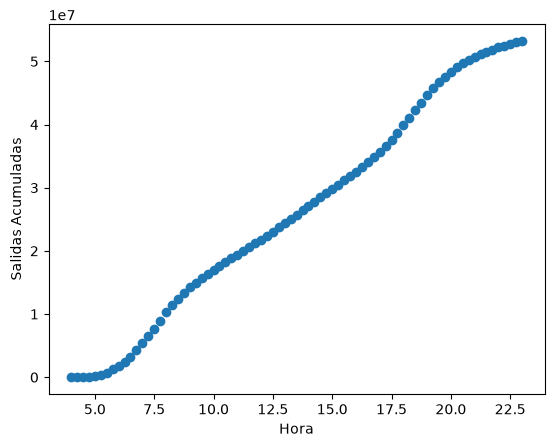

In [8]:
#se grafica el acumulado para cada hora
x = df1c['Hora']
y = df1c['Acumulado']

plt.scatter(x, y)

plt.xlabel('Hora')
plt.ylabel('Salidas Acumuladas')
plt.show

# Regresión Lineal (Ecuaciones Normales)

In [9]:
#variables para ecuaciones normales
n = len(x)
Sx = np.sum(x)
Sy = np.sum(y)
Sxy = np.sum(x*y)
Sxx = np.sum(x*x)

print(f'Sx = {Sx}, Sy = {Sy}, Sxx = {Sxx}, Sxy = {Sxy}')

Sx = 1039.5, Sy = 2034450558, Sxx = 16410.625, Sxy = 34729423446.5


w1 0 3055614.244071718, w0 = -14829356.476786371


<function matplotlib.pyplot.show(close=None, block=None)>

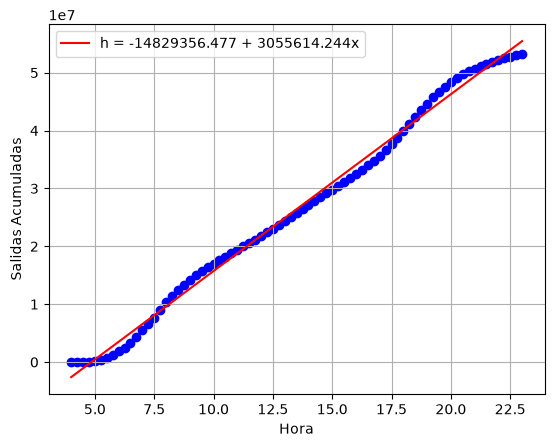

In [10]:
#ecuaciones normales
w1 = (n*Sxy - Sx*Sy)/(n*Sxx - Sx*Sx)
w0 = np.mean(y) - w1*np.mean(x)

print(f'w1 0 {w1}, w0 = {w0}')

h = w0 + w1*x

plt.scatter(x, y, color='blue')
plt.plot(x, h, color='red', label = f"h = {round(w0, 3)} + {round(w1, 3)}x")

plt.xlabel('Hora')
plt.ylabel('Salidas Acumuladas')
plt.legend()
plt.grid()
plt.show

# Regresión Lineal (Descenso del Gradiente)

<function matplotlib.pyplot.show(close=None, block=None)>

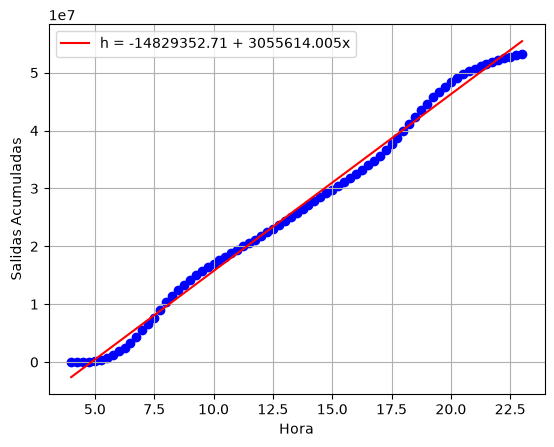

In [14]:
#definir el factor de aprendizaje
a = 0.0093

#inicializar los parámetros
W0 = np.random.randint(1, 10)
W1 = np.random.randint(1, 10)

epsilon = 0.001

#inicializar las funciones de costo
J = 1
J_k = 2
t = 0
J_array = []
W1_array = []
W0_array = []
epoca = []

while abs(J-J_k) >= epsilon:
    J = 1/(2*n) * np.sum((W0 + W1*x - y)**2)
    J_array.append(J)
    W1_array.append(W1)
    W0_array.append(W0)

    #para calcular W1 con el W0 del bucle anterior
    aux = W0
    
    #actualizar los parámetros
    W0 -= a/n*(n*W0 + W1*Sx - Sy)
    W1 -= a/n*(aux*Sx + W1*Sxx - Sxy)

    #nueva función de costo
    J_k = 1/(2*n) * np.sum((W0 + W1*x - y)**2)

    epoca.append(t)
    t += 1

#función de hipótesis
H = W0 + W1*x

plt.scatter(x, y, color='blue')
plt.plot(x, H, color='red', label = f"h = {round(W0, 3)} + {round(W1, 3)}x")

plt.xlabel('Hora')
plt.ylabel('Salidas Acumuladas')
plt.legend()
plt.grid()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

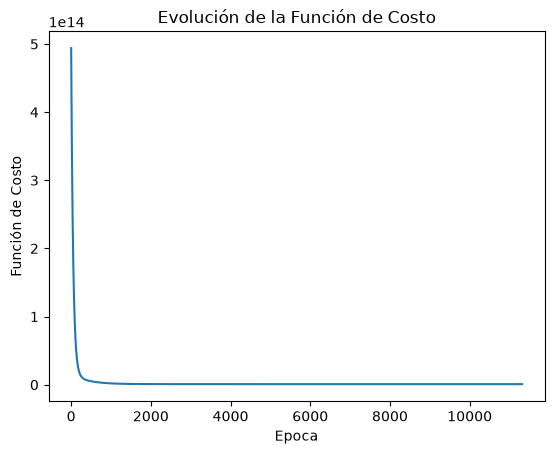

In [21]:
plt.plot(epoca, J_array)

plt.title('Evolución de la Función de Costo')
plt.xlabel('Epoca')
plt.ylabel('Función de Costo')
plt.show

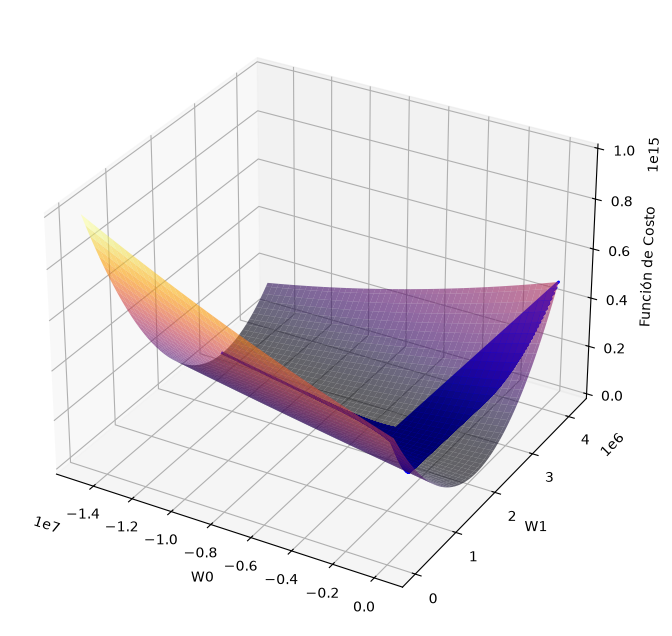

In [27]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Recorrido del descenso de gradiente
ax.plot(W0_array, W1_array, J_array, color='blue', linewidth=2)

# dibujar toda la función de costo
W0_vals = np.linspace(min(W0_array), max(W0_array), 100)
W1_vals = np.linspace(min(W1_array), max(W1_array), 100)

W0_grid, W1_grid = np.meshgrid(W0_vals, W1_vals)


J_grid = np.zeros_like(W0_grid)

for i in range(W0_grid.shape[0]):
    for j in range(W0_grid.shape[1]):
        J_grid[i, j] = 1/(2*n) * np.sum(
            (W0_grid[i, j] + W1_grid[i, j] * x - y)**2
        )


ax.plot_surface(
    W0_grid,
    W1_grid,
    J_grid,
    cmap='inferno',
    alpha=0.6
)

ax.set_xlabel('W0')
ax.set_ylabel('W1')
ax.set_zlabel('Función de Costo')

plt.show()
